<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Comic%20Books%20Dataset%20(10%2C000-entries)%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comic Books Dataset (10,000 entries)


# Unveiling the World of Comic Books: A Data-Driven Journey

Our exploration delved into a rich dataset comprising 10,000 comic book entries, each meticulously detailed across 17 different attributes, ranging from Title and Writer to Page Count and Audience Rating. This extensive collection provided a robust foundation for uncovering fascinating patterns and drivers within the comic book industry.

Core Dataset Characteristics
Initially, we observed that the dataset was remarkably clean, with no duplicate entries. However, a significant portion of entries (over 60%) lacked information on Awards, suggesting that not every comic is submitted for or receives formal recognition. The majority of comics were Completed series, frequently released as Tankobon volumes, with Black & White art styles dominating. English and Japanese were the most prevalent languages, catering primarily to Teen+ and Mature audiences.

Key Insights from Data Analysis
Content-Density Paradox: A crucial finding emerged when examining the relationship between Page Count and Audience Rating. Contrary to what some might assume, a statistically significant positive correlation was identified (Spearman coefficient: 0.1605, p-value: 1.12e-58). This suggests that high-density content—comics with more pages—tend to mathematically yield higher audience reception. Readers, it seems, appreciate the depth and length.

The Elusive Prestige Premium: We hypothesized that award-winning comics might inherently possess a higher average audience rating. However, a Welch's T-Test revealed that the difference in average ratings between awarded (8.06) and standard (8.05) releases was not statistically significant (p-value: 0.2321e-01). This indicates a potential disconnect between industry accolades and mass-audience perception, suggesting that critical acclaim doesn't always perfectly align with general popularity.

Brand Power in Publishing: Investigating the impact of publishers on ratings, a One-Way ANOVA on the top 5 publishers demonstrated a statistically significant variance in ratings across different studios (p-value: 2.2485e-31). This strongly implies that a publisher's brand name carries substantial weight, influencing baseline audience reception. Not all publishers are judged equally in the marketplace.

Advanced Analytics: Decoding Hidden Drivers
The Language of Titles: Through TF-IDF and Ridge Regression, we analyzed the keywords in comic book titles. Keywords like 'crimson', 'story', and 'zero' were found to boost ratings, while terms such as 'manhua', 'wood', and 'noise' surprisingly corresponded to lower ratings. This provides valuable insight into the linguistic psychology of comic book titles.

Multivariate Audience Drivers: An OLS Regression model, controlling for various factors, highlighted several formats that mathematically dictate higher baseline ratings. Notably, Tankobon, Digital Manga, Manga Volume, and Webtoon formats showed significant positive impacts on audience ratings, even when accounting for other variables.

Creator Synergy: Certain writer-artist collaborations consistently achieved higher ratings. Top "dream teams" like 'Naruto Uzumaki style & Gintoki Sakata' and 'Ryota Nakamura & Vegeta style' demonstrated a 'Prestige Multiplier', outperforming individual average ratings, underscoring the power of creative partnerships.

Predictive Modeling & Feature Importance
Finally, a machine learning pipeline was built to predict comic book ratings. After extensive feature engineering, a Random Forest Regressor model emerged as the best performer, achieving a Mean Absolute Error (MAE) of 0.41 rating points and an R-squared (R2) of 0.0850. This indicates that the model can predict ratings with reasonable accuracy, typically being off by less than half a point. The most influential features driving these predictions were Writer_Encoded, Artist_Encoded, and the Title_Semantic_Vector_1, revealing the paramount importance of creative talent and thematic content in determining a comic's success.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d rudrakumargupta/comic-books-dataset-10000-entries

# Unziping the downloaded file
!unzip comic-books-dataset-10000-entries.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rudrakumargupta/comic-books-dataset-10000-entries
License(s): CC0-1.0
  0% 0.00/423k [00:00<?, ?B/s]
100% 423k/423k [00:00<00:00, 847MB/s]
Archive:  comic-books-dataset-10000-entries.zip
  inflating: comic_books_10000_dataset.csv  


# Data Inspection

In [3]:
df = pd.read_csv('comic_books_10000_dataset.csv')
df.head(11)

,comic_id,Title,Writer,Artist,Studio/Publisher,Release Year,Format,Theme (Color Style),Genre,Country of Origin,Page Count,Rating (out of 10),Status,Language,Age Rating,Awards,Volume Count
0,CMC-00001,Tiger of Zero,Gintoki Sakata,Gintoki Sakata,Shogakukan (Viz Media),2001,Tankobon,Full Color (Special Edition),Shoujo / Romance,Japan,890,8.0,Ongoing,Japanese,Mature,NaN,13
1,CMC-00002,Twisted Claw,Fumi Takahashi,Mika Sasaki,Shogakukan (Viz Media),2015,Tankobon,Black & White,Action / Historical,Japan,2850,8.3,Completed,Japanese,Mature,NaN,12
2,CMC-00003,Jean Grey: Rebirth,Chip Zdarsky,Bendis,Marvel Comics,2016,Graphic Novel,Full Color,Superhero / Thriller,USA,350,7.8,Ongoing,English,Teen+,Japan Media Arts Award Winner,13
3,CMC-00004,Abyss Destiny,Yuna Yamaguchi,Yuna Yamaguchi,Kodansha (Kodansha USA),2014,Manga Volume,Black & White,Slice of Life / Drama,Japan,592,8.7,Cancelled,Japanese,Teen+,Eisner Award Nominee,13
4,CMC-00005,After Smoke,Shannon Watters,Warren Ellis,Kodansha Comics,2005,OGN,Black & White,Romance / Drama,USA,2465,7.0,Ongoing,English,Mature,NaN,4
5,CMC-00006,Ghost Memory,Ryota Nakamura,Ryu Hashimoto,Shueisha (Manga Plus),2015,Manga Volume,Black & White,Action / Fantasy,Japan,774,8.8,Completed,Japanese,All Ages,Harvey Award Nominee,34
6,CMC-00007,Ancient X,Kazushi Hagiwara,Vegeta style,Square Enix (Yen Press),2017,Manga Volume,Black & White,Romance / Comedy,Japan,4186,8.0,Ongoing,Japanese,Mature,NaN,43
7,CMC-00008,Luminous Empire,Hana Yamashita,Hiroyuki Takei,Shogakukan (Viz Media),2012,Manga Volume,Grayscale,Music / Drama,Japan,6498,8.2,Ongoing,Japanese,Mature,Harvey Award Nominee,12
8,CMC-00009,Day Fang,Akira Toriyama,Luffy style,Kodansha (Kodansha USA),2023,Single Issue / Tankobon,Black & White,Historical / Drama,Japan,1455,8.5,Completed,Japanese,Teen+,NaN,19
9,CMC-00010,Immortal Knight,Vegeta style,Vegeta style,Leed-sha,2024,Digital Manga,Black & White,Historical / Drama,Japan,3693,8.0,Ongoing,Japanese,Mature,Japan Media Arts Award Winner,39


In [4]:
df.tail(11)

,comic_id,Title,Writer,Artist,Studio/Publisher,Release Year,Format,Theme (Color Style),Genre,Country of Origin,Page Count,Rating (out of 10),Status,Language,Age Rating,Awards,Volume Count
9989,CMC-09990,Villain Thunder Guild,Oh Jae-won,Oh Jae-won,MangaToon,2015,Webtoon,Full Color (Pastel),Sports / Action,South Korea,3448,8.6,Ongoing,Korean,Teen+,Kodansha Manga Award Winner,9
9990,CMC-09991,Scarlet Archive,Sora Fujimoto,Takashi Yamamoto,Akita Shoten,2006,Tankobon,Black & White,Comedy / Slice of Life,Japan,4842,8.3,Ongoing,Japanese,Teen+,Eisner Award Nominee,32
9991,CMC-09992,Stone of Ice,Skottie Young,Chester Brown,Oni Press,2024,Trade Paperback,Full Color / Limited Palette,Cyberpunk / Sci-Fi,Australia,509,8.0,Ongoing,English,Mature 17+,Eisner Award Winner,9
9992,CMC-09993,Shadow I Solo Awakening,Manhwaga K,Manhwaga K,MangaToon,2016,Webtoon Chapter Collection,Full Color (Digital),Drama / Romance,South Korea / USA,4511,8.1,Completed,Korean,Young Adult,NaN,15
9993,CMC-09994,Ashen God,Sora Fujimoto,Sora Fujimoto,Square Enix (Yen Press),2005,Manga Volume,Black & White,Action / Supernatural,Japan,2540,7.5,Ongoing,Japanese,Mature,Angouleme Award Winner,37
9994,CMC-09995,Blue and Ice,Alan Moore,Alan Moore,Antarctic Press,2024,Omnibus,Black & White,Magical Realism / Drama,UK,910,6.8,Completed,English,Mature,NaN,6
9995,CMC-09996,Forsaken Reincarnation,Kai Yoshida,Kai Yoshida,Leed-sha,2019,Single Issue / Tankobon,Black & White,Psychological / Thriller,Japan,4143,7.9,Ongoing,Japanese,Young Adult,NaN,15
9996,CMC-09997,Lion Memory,Daisuke Imai,Mitsuru Adachi,Ichijinsha,2019,Manga Volume,Black & White,School / Romance,Japan,2987,8.3,Hiatus,Japanese,Teen+,NaN,45
9997,CMC-09998,Legendary F-Ranked Void System,Nam Hyun-jun,Go Chan,Kakao Webtoon,2017,Digital Webtoon,Full Color / Limited Palette,Reincarnation / Fantasy,South Korea,1548,6.9,Ongoing,Korean,Mature,NaN,13
9998,CMC-09999,The Lost Gold,Noelle Stevenson,Faith Erin Hicks,Drawn & Quarterly,2023,Omnibus,Black & White,Adventure / Comedy,New Zealand,1758,7.2,Completed,English,Mature,NaN,8


In [5]:
df.shape

(10000, 17)

In [6]:
df.columns

Index(['comic_id', 'Title', 'Writer', 'Artist', 'Studio/Publisher',
       'Release Year', 'Format', 'Theme (Color Style)', 'Genre',
       'Country of Origin', 'Page Count', 'Rating (out of 10)', 'Status',
       'Language', 'Age Rating', 'Awards', 'Volume Count'],
      dtype='object')

In [7]:
df.dtypes

,0
comic_id,object
Title,object
Writer,object
Artist,object
Studio/Publisher,object
Release Year,int64
Format,object
Theme (Color Style),object
Genre,object
Country of Origin,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   comic_id             10000 non-null  object 
 1   Title                10000 non-null  object 
 2   Writer               10000 non-null  object 
 3   Artist               10000 non-null  object 
 4   Studio/Publisher     10000 non-null  object 
 5   Release Year         10000 non-null  int64  
 6   Format               10000 non-null  object 
 7   Theme (Color Style)  10000 non-null  object 
 8   Genre                10000 non-null  object 
 9   Country of Origin    10000 non-null  object 
 10  Page Count           10000 non-null  int64  
 11  Rating (out of 10)   10000 non-null  float64
 12  Status               10000 non-null  object 
 13  Language             10000 non-null  object 
 14  Age Rating           10000 non-null  object 
 15  Awards               3984 non-null   

In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
comic_id,10000,10000,CMC-09984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,10000,8158,Noise Road,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Writer,10000,327,Ed Brubaker,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artist,10000,343,Ed Brubaker,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Studio/Publisher,10000,111,Marvel Comics,1218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Release Year,10000.0,NaN,NaN,NaN,2015.4959,7.438381,2000.0,2010.0,2017.0,2022.0,2026.0
Format,10000,20,Tankobon,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Theme (Color Style),10000,8,Black & White,3143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,10000,105,Horror / Supernatural,295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country of Origin,10000,21,Japan,3575,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.isnull().sum()

,0
comic_id,0
Title,0
Writer,0
Artist,0
Studio/Publisher,0
Release Year,0
Format,0
Theme (Color Style),0
Genre,0
Country of Origin,0


In [11]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

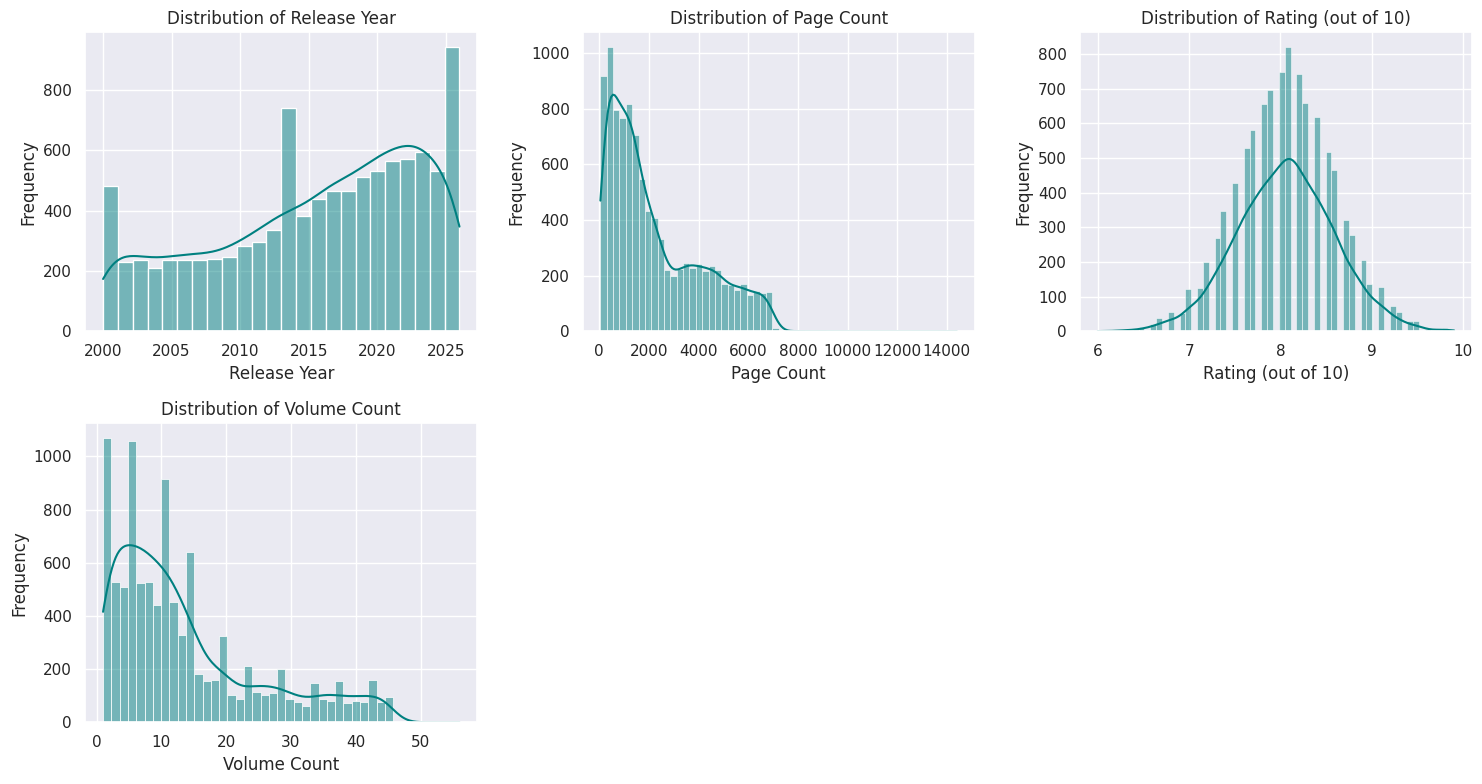

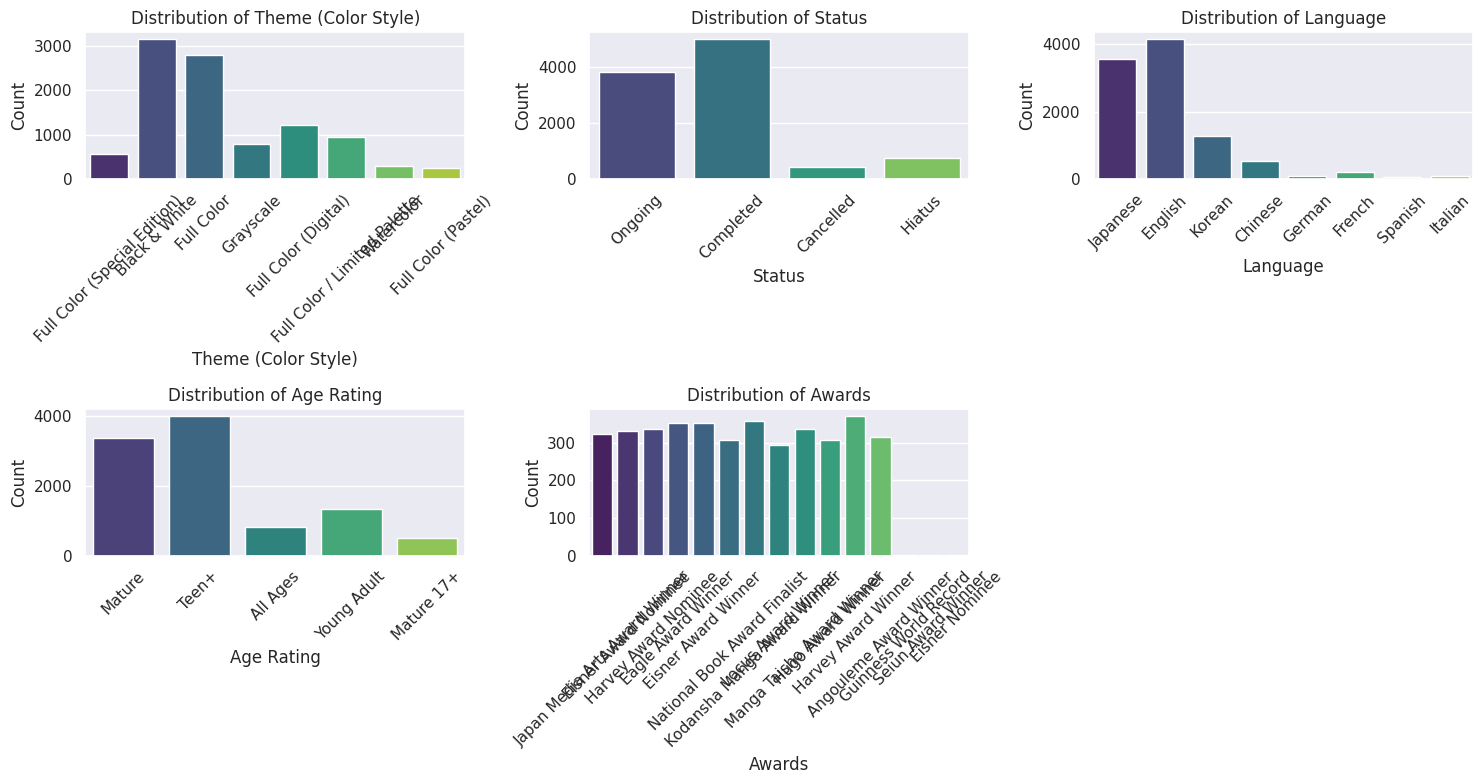

--- Categorical Value Counts ---

Value counts for Theme (Color Style):
Theme (Color Style)
Black & White                   3143
Full Color                      2791
Full Color (Digital)            1227
Full Color / Limited Palette     935
Grayscale                        792
Full Color (Special Edition)     570
Watercolor                       289
Full Color (Pastel)              253
Name: count, dtype: int64

Value counts for Status:
Status
Completed    5005
Ongoing      3820
Hiatus        741
Cancelled     434
Name: count, dtype: int64

Value counts for Language:
Language
English     4146
Japanese    3575
Korean      1263
Chinese      550
French       218
Italian       92
German        81
Spanish       75
Name: count, dtype: int64

Value counts for Age Rating:
Age Rating
Teen+          3996
Mature         3367
Young Adult    1326
All Ages        819
Mature 17+      492
Name: count, dtype: int64

Value counts for Awards:
Awards
Harvey Award Winner              371
Kodansha Manga Awar

In [12]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

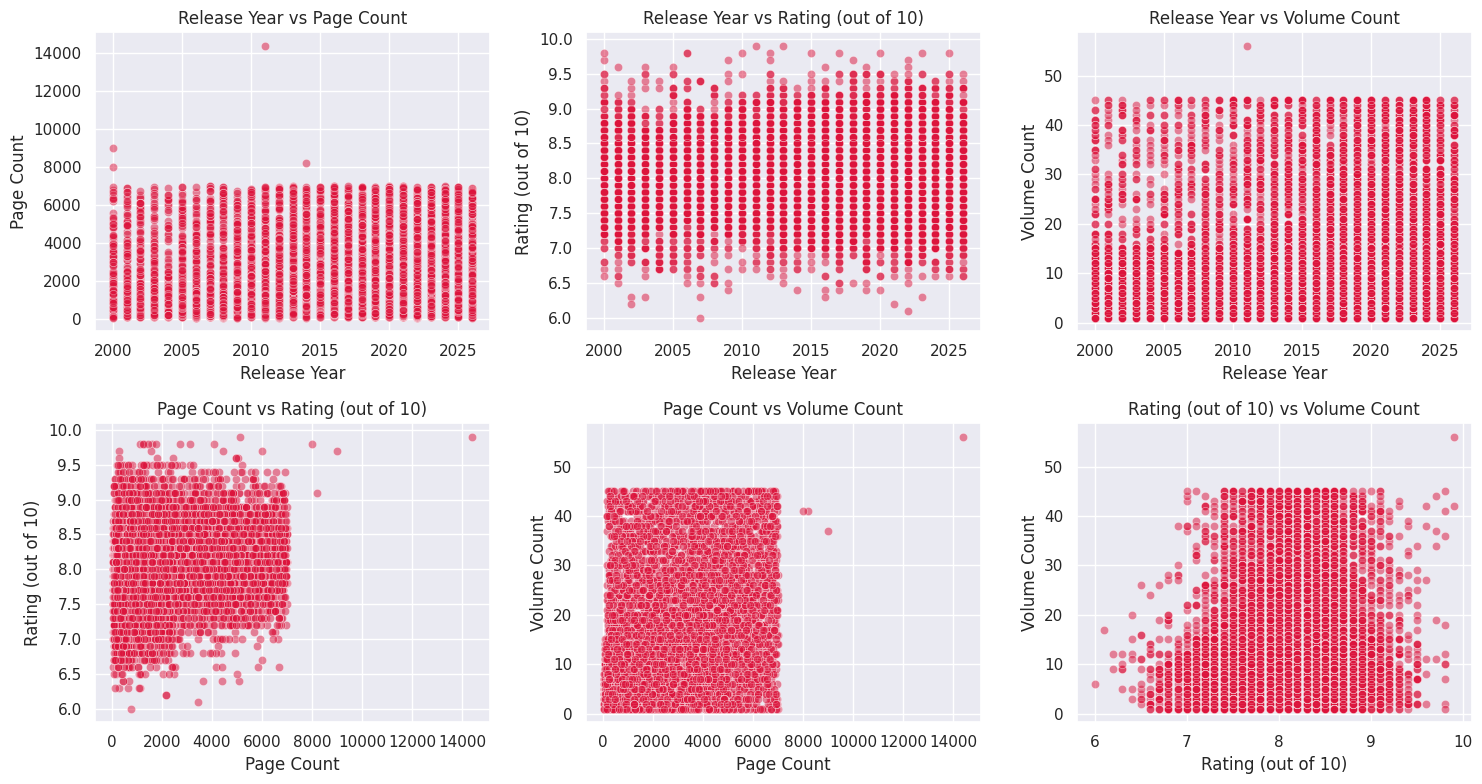

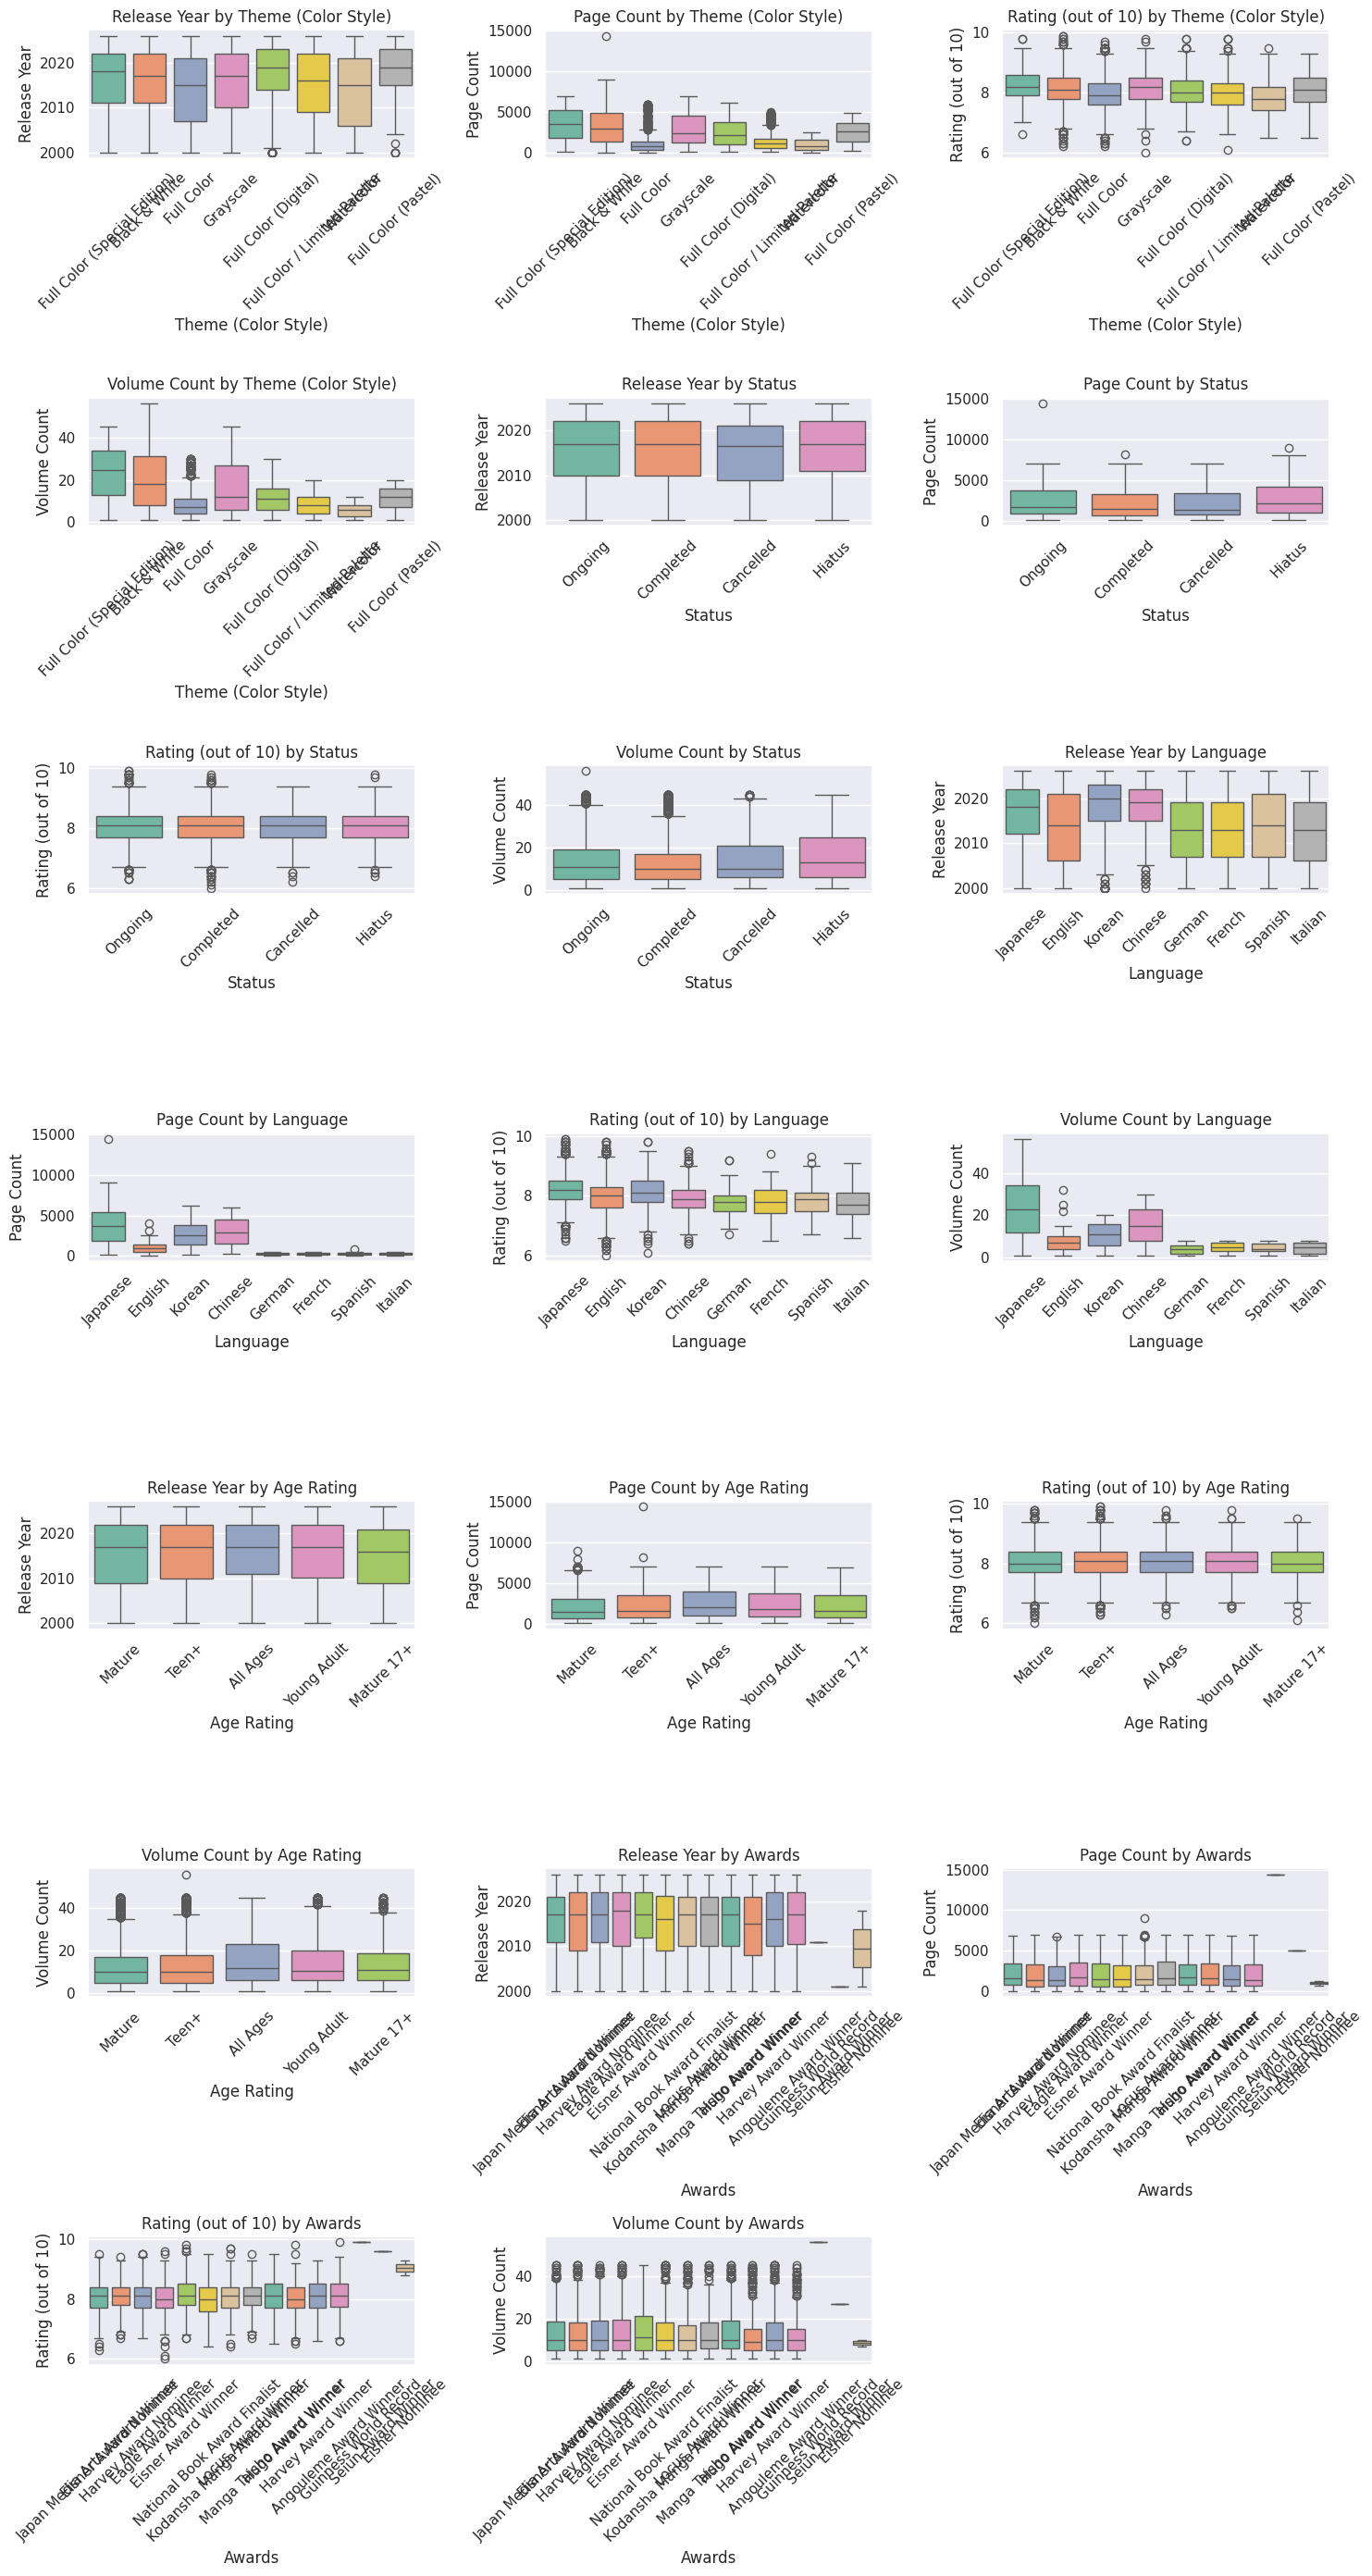

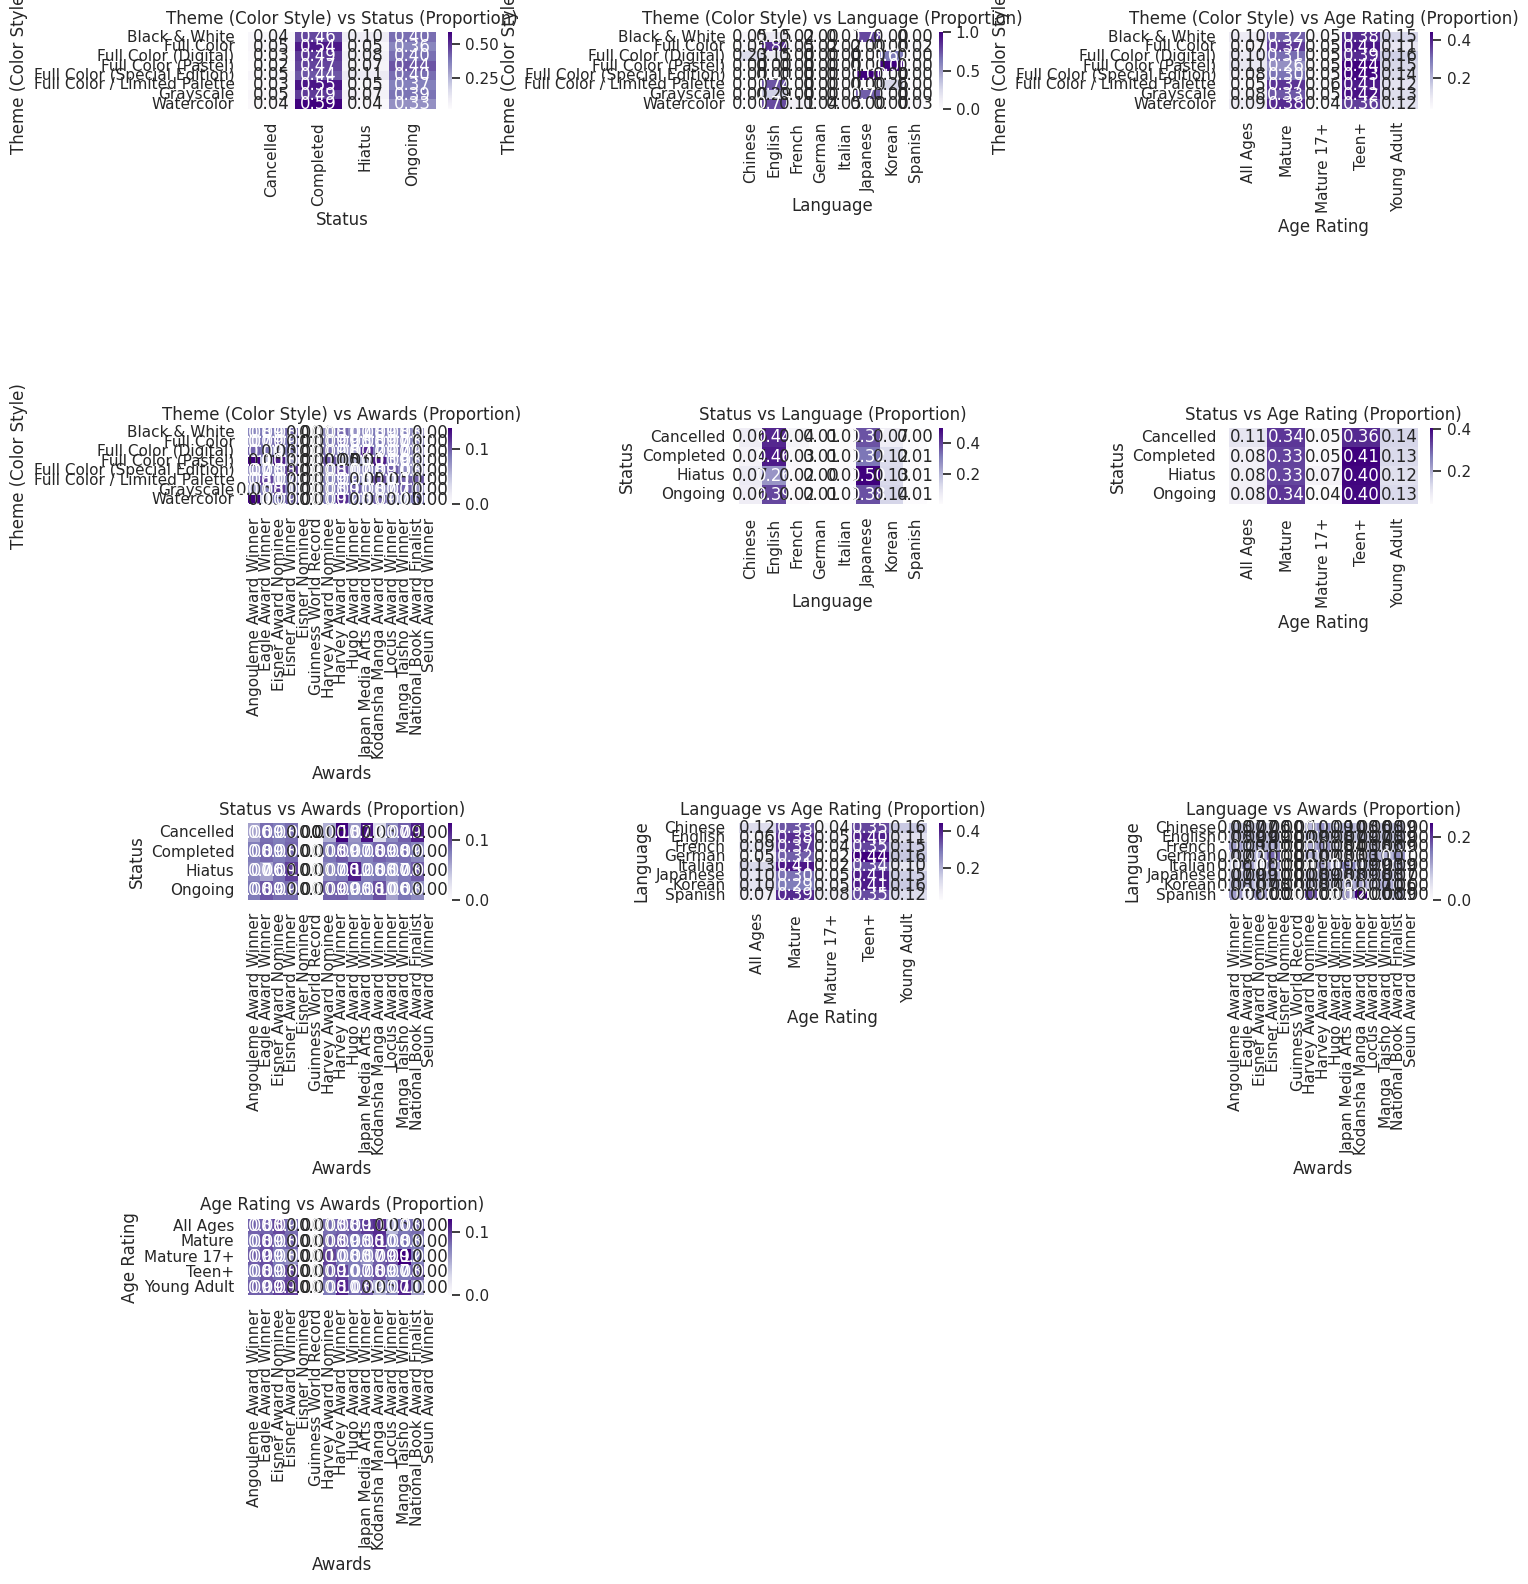

In [13]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: Theme (Color Style)...


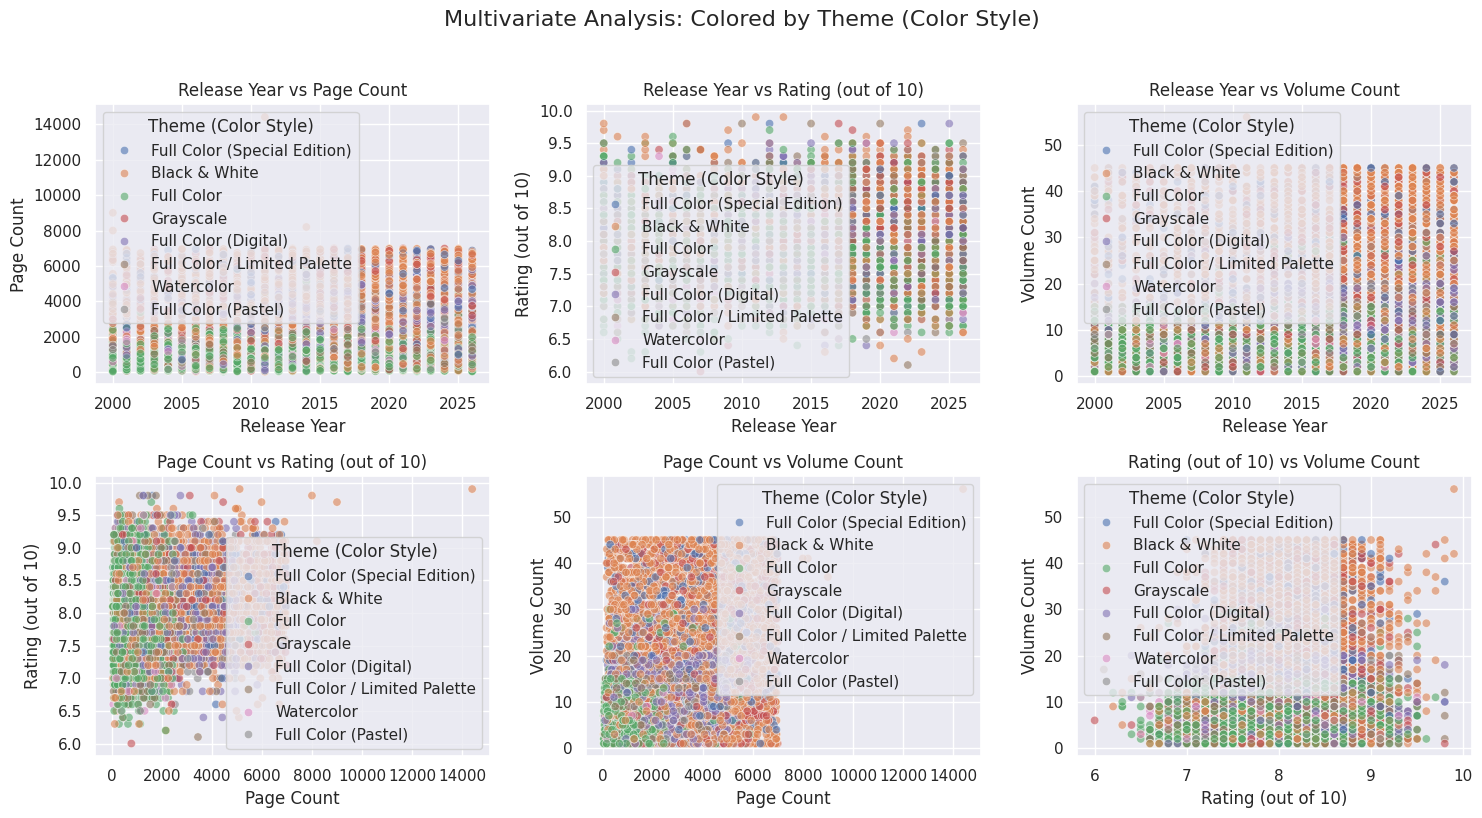


Analyzing relationships with Hue: Status...


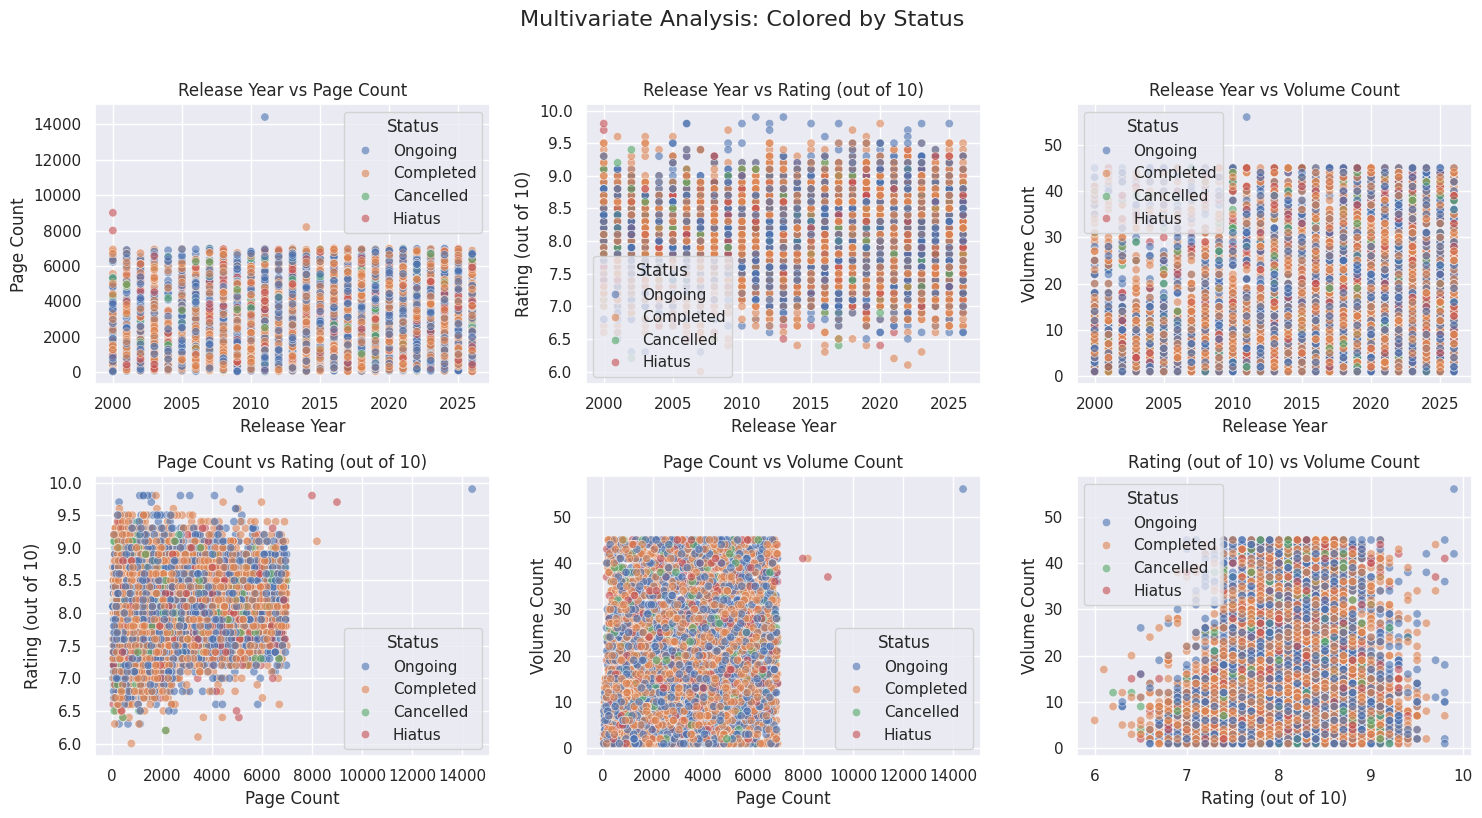


Analyzing relationships with Hue: Language...


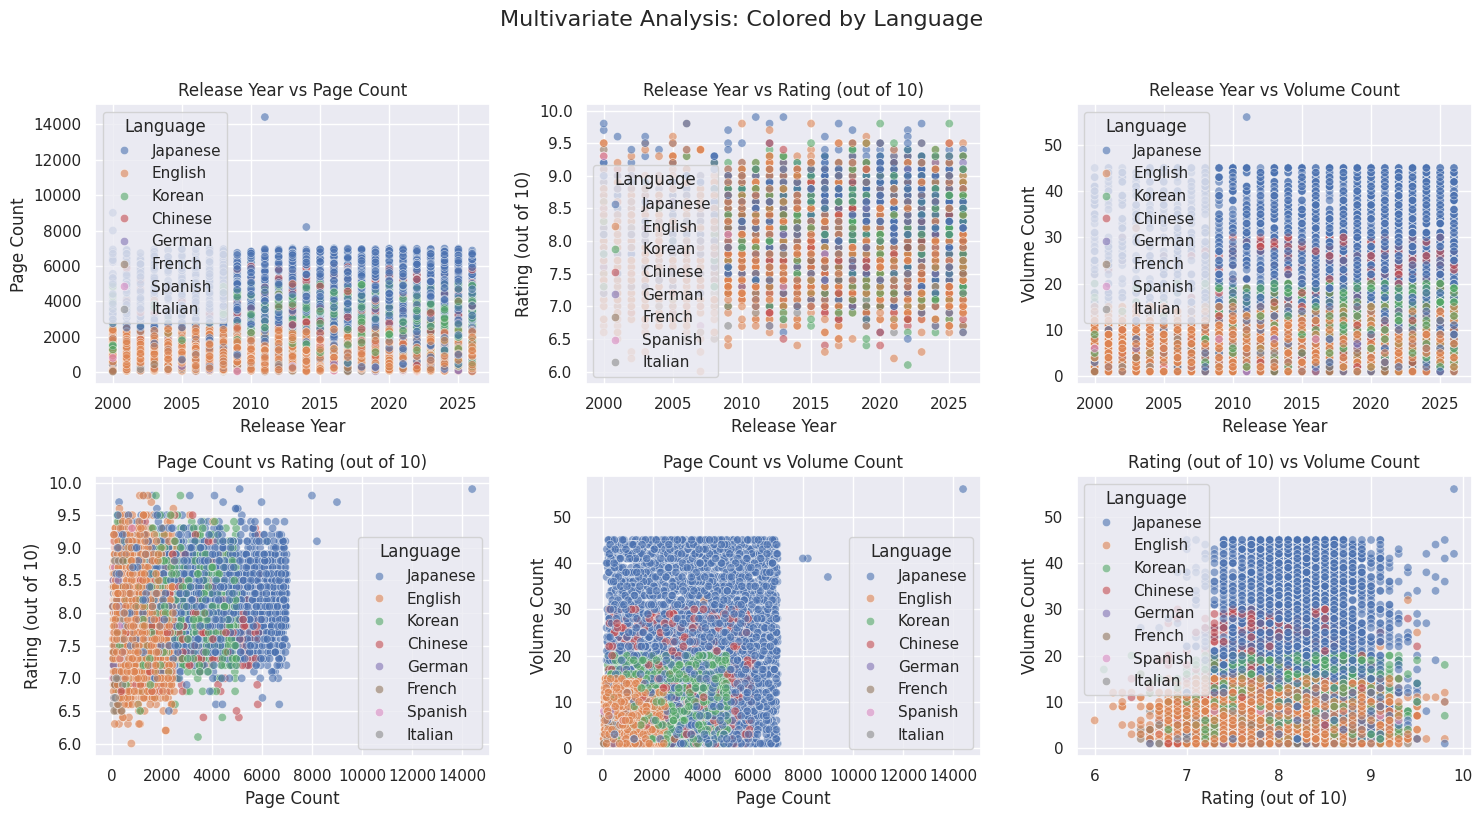


Analyzing relationships with Hue: Age Rating...


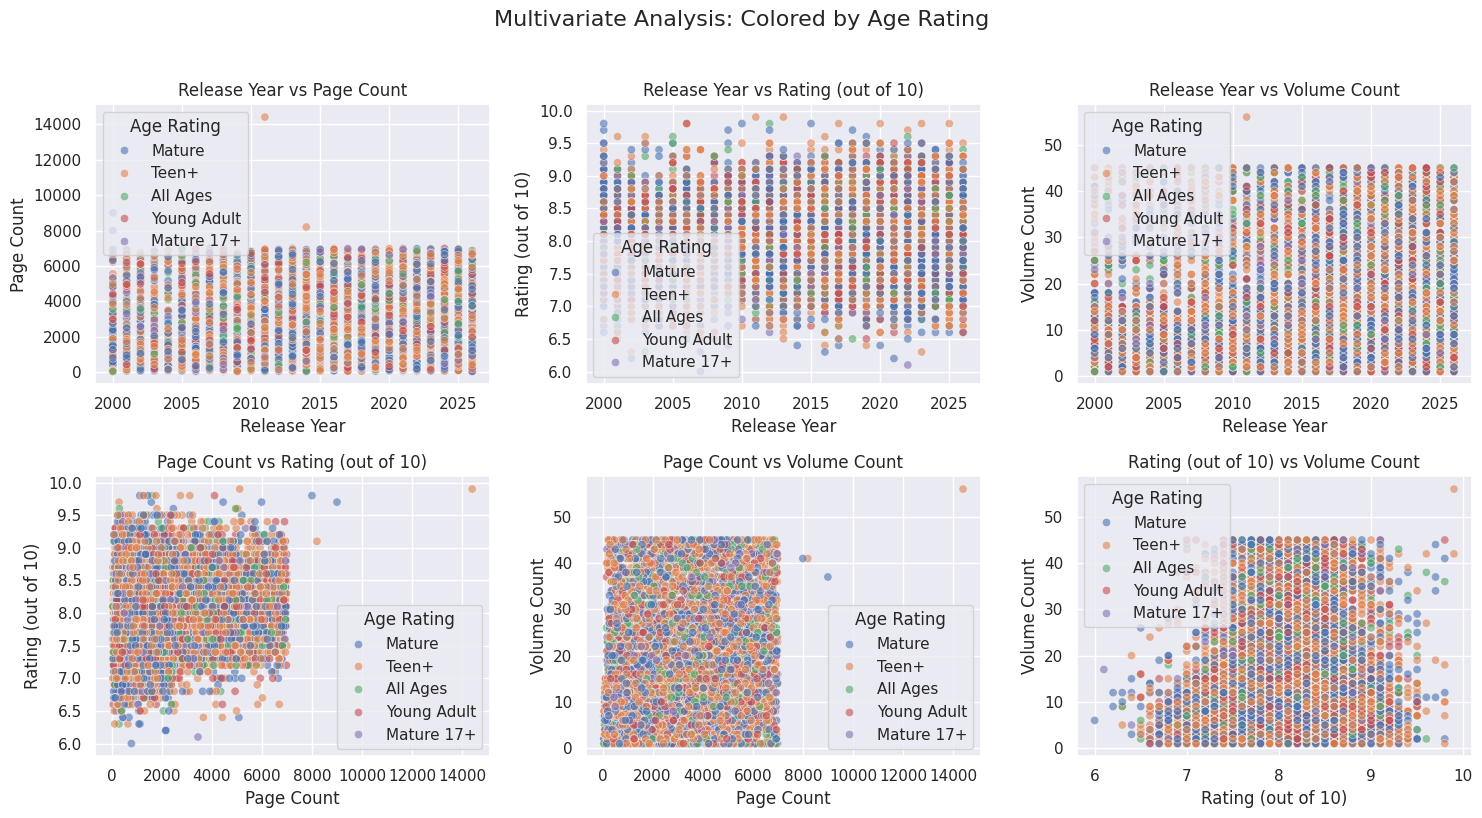

In [14]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

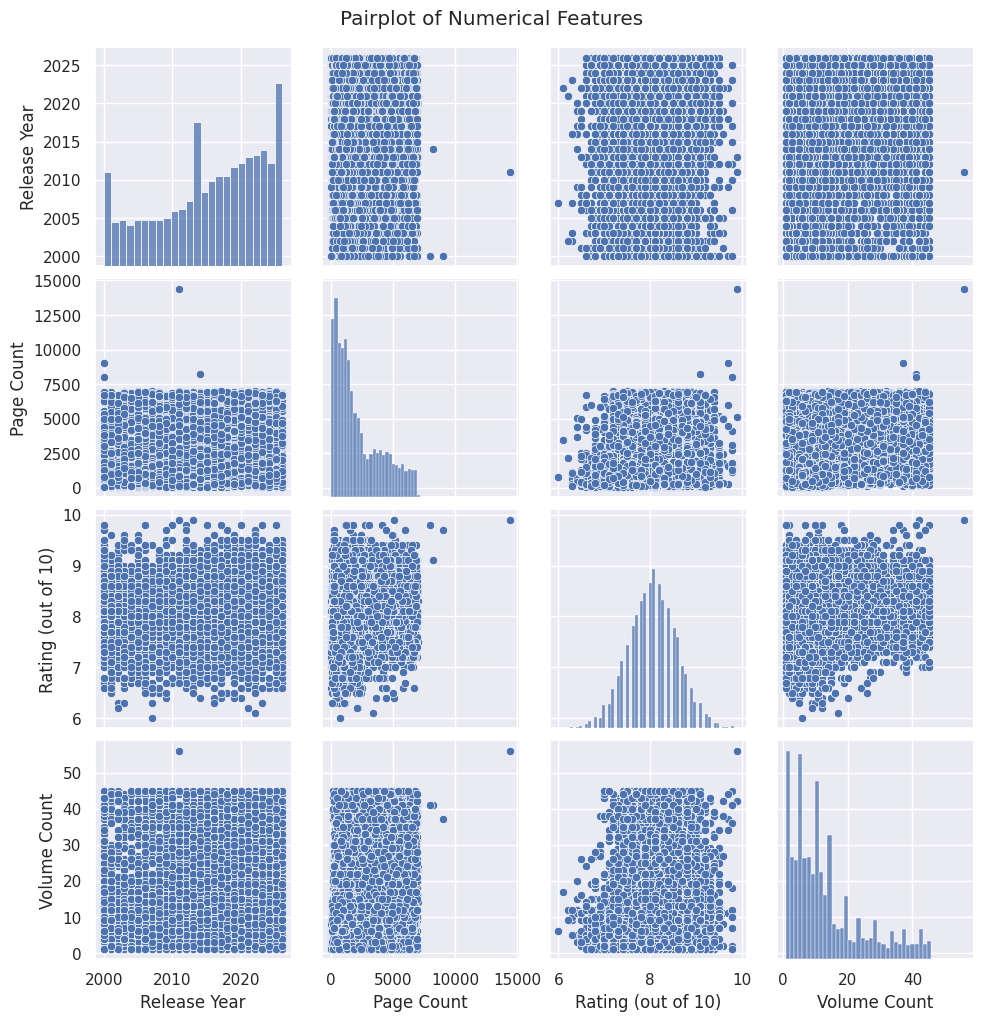

In [15]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

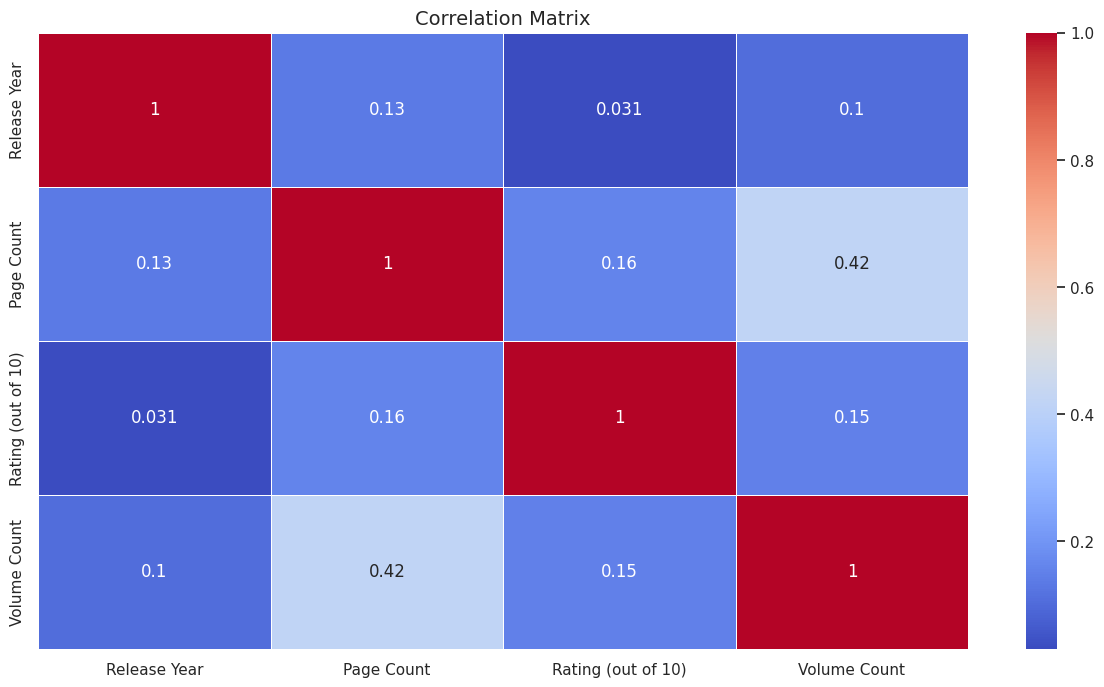

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

## Media Feature Engineering & Statistical Diagnostics

--- 1. ENGINEERING PRESTIGE & ERA METRICS ---
 Engineered: Binary 'Has_Award' vector and 'Publishing_Decade' cohorts.

--- 2. THE CONTENT-DENSITY PARADOX (SPEARMAN RANK CORRELATION) ---
Spearman Correlation Coefficient (Pages vs. Rating): 0.1605
P-Value: 1.1209e-58
 Insight: Positive correlation detected. High-density content mathematically yields higher audience reception.


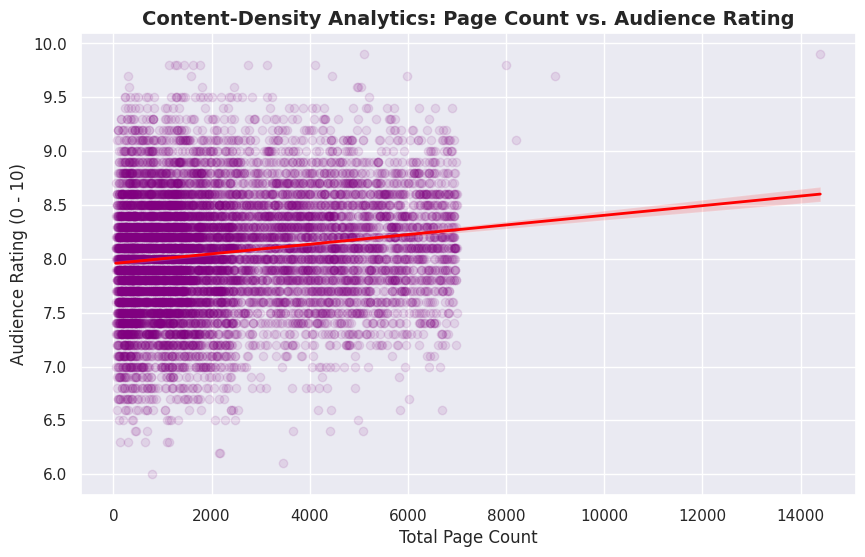


--- 3. THE PRESTIGE PREMIUM (WELCH'S T-TEST) ---
Avg Award-Winning Rating: 8.06
Avg Standard Rating: 8.05
Welch's T-Test P-Value: 2.3210e-01
 Insight: Industry awards are mathematically disconnected from mass-audience ratings (The 'Critics vs. Audience' divide).


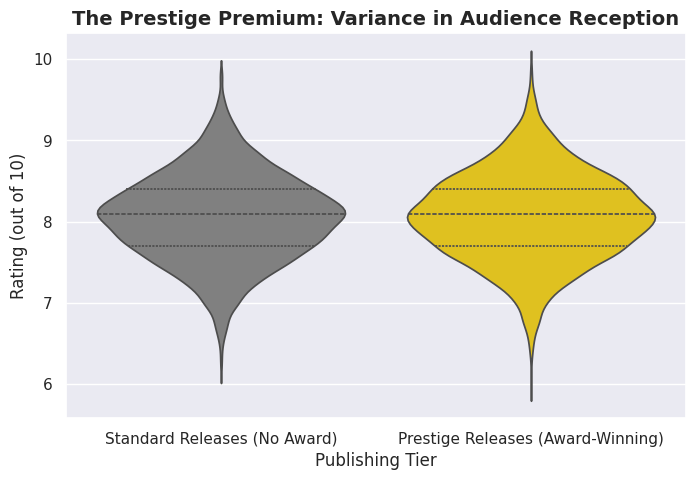


--- 4. THE BRAND POWER METRIC (ONE-WAY ANOVA) ---
ANOVA P-Value (Brand Variance): 2.2485e-31
 Insight: The variance in ratings across the Top 5 Publishers is statistically significant.
 -> 'Brand Name' structurally dictates audience reception. Not all publishers are judged equally.


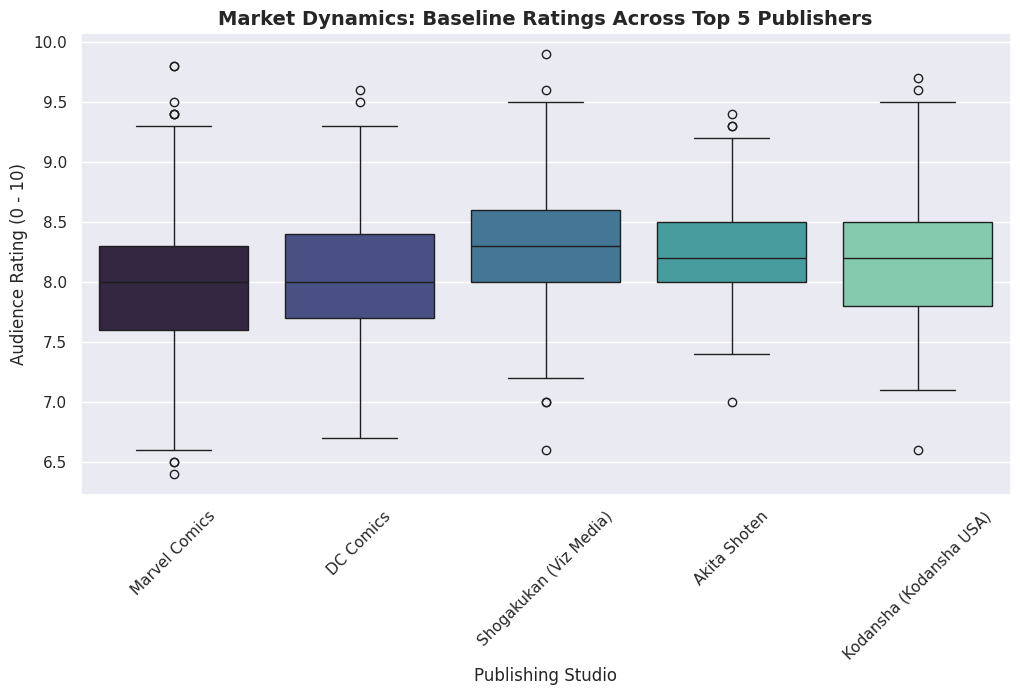

In [18]:
import scipy.stats as stats

print("--- 1. ENGINEERING PRESTIGE & ERA METRICS ---")
# To analyzing awards mathematically, we must convert the 'Awards' text column into a binary vector.
# Assuming 'Awards' contains text or NaNs/None for books without awards.

# Creating a binary 'Has_Award' feature
df['Has_Award'] = np.where(df['Awards'].astype(str).str.len() > 4, 1, 0)

# Creating a 'Publishing_Decade' for macro-trend analysis
df['Publishing_Decade'] = (df['Release Year'] // 10) * 10

print(" Engineered: Binary 'Has_Award' vector and 'Publishing_Decade' cohorts.")


# :::::: PUBLISHING HYPOTHESIS TESTING ::::::

print("\n--- 2. THE CONTENT-DENSITY PARADOX (SPEARMAN RANK CORRELATION) ---")
# Does a massive Page Count equal a better Rating?
# Because audience ratings (0-10) are bounded and non-linear, we deploy Spearman's Rank.

corr_data = df[['Page Count', 'Rating (out of 10)']].dropna()
spearman_coef, p_val_spearman = stats.spearmanr(corr_data['Page Count'], corr_data['Rating (out of 10)'])

print(f"Spearman Correlation Coefficient (Pages vs. Rating): {spearman_coef:.4f}")
print(f"P-Value: {p_val_spearman:.4e}")

if p_val_spearman < 0.05:
    if spearman_coef > 0:
        print(" Insight: Positive correlation detected. High-density content mathematically yields higher audience reception.")
    else:
        print(" Insight: Negative correlation detected. Reader fatigue is real; longer page counts statistically damage the rating.")
else:
    print(" Insight: Null Hypothesis accepted. Page Count has absolutely zero mathematical impact on how much the audience enjoys the comic.")

# Visualizing the Paradox
plt.figure(figsize=(10, 6))
sns.regplot(x='Page Count', y='Rating (out of 10)', data=corr_data,
            scatter_kws={'alpha':0.1, 'color':'purple'}, line_kws={'color':'red', 'linewidth':2})
plt.title('Content-Density Analytics: Page Count vs. Audience Rating', fontsize=14, fontweight='bold')
plt.xlabel('Total Page Count')
plt.ylabel('Audience Rating (0 - 10)')
plt.show()


print("\n--- 3. THE PRESTIGE PREMIUM (WELCH'S T-TEST) ---")
# Do award-winning comics hold a mathematically distinct rating advantage
# over standard, un-awarded releases?

awarded_ratings = df[df['Has_Award'] == 1]['Rating (out of 10)'].dropna()
standard_ratings = df[df['Has_Award'] == 0]['Rating (out of 10)'].dropna()

# We use Welch's T-Test (equal_var=False) because the variance of the unawarded majority
# will be vastly different from the awarded elite minority.
t_stat, p_val_ttest = stats.ttest_ind(awarded_ratings, standard_ratings, equal_var=False)

print(f"Avg Award-Winning Rating: {awarded_ratings.mean():.2f}")
print(f"Avg Standard Rating: {standard_ratings.mean():.2f}")
print(f"Welch's T-Test P-Value: {p_val_ttest:.4e}")

if p_val_ttest < 0.05:
    print(" Insight: The Prestige Premium is statistically significant.")
    print(" -> Industry awards perfectly align with higher mass-audience reception.")
else:
    print(" Insight: Industry awards are mathematically disconnected from mass-audience ratings (The 'Critics vs. Audience' divide).")

# Visualizing the Prestige Premium
plt.figure(figsize=(8, 5))
sns.violinplot(x='Has_Award', y='Rating (out of 10)', data=df, palette=['gray', 'gold'], inner='quartile')
plt.xticks([0, 1], ['Standard Releases (No Award)', 'Prestige Releases (Award-Winning)'])
plt.title('The Prestige Premium: Variance in Audience Reception', fontsize=14, fontweight='bold')
plt.xlabel('Publishing Tier')
plt.ylabel('Rating (out of 10)')
plt.show()


print("\n--- 4. THE BRAND POWER METRIC (ONE-WAY ANOVA) ---")
# Hypothesis: Does the Publisher fundamentally dictate the baseline rating of a comic book?
# We will test the Top 5 most frequent publishers in the dataset.

# Identify the Top 5 Publishers by volume
top_5_publishers = df['Studio/Publisher'].value_counts().head(5).index.tolist()

if len(top_5_publishers) > 0:
    # Filtering dataset and group the ratings
    top_publishers_df = df[df['Studio/Publisher'].isin(top_5_publishers)]
    brand_groups = [top_publishers_df[top_publishers_df['Studio/Publisher'] == brand]['Rating (out of 10)'].dropna() for brand in top_5_publishers]

    f_stat, p_val_anova = stats.f_oneway(*brand_groups)

    print(f"ANOVA P-Value (Brand Variance): {p_val_anova:.4e}")
    if p_val_anova < 0.05:
        print(" Insight: The variance in ratings across the Top 5 Publishers is statistically significant.")
        print(" -> 'Brand Name' structurally dictates audience reception. Not all publishers are judged equally.")
    else:
        print(" Insight: The market is a pure meritocracy. The Publisher logo on the cover has zero mathematical impact on the rating.")

    # Visualizing Brand Power::
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Studio/Publisher', y='Rating (out of 10)', data=top_publishers_df, order=top_5_publishers, palette='mako')
    plt.title('Market Dynamics: Baseline Ratings Across Top 5 Publishers', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.xlabel('Publishing Studio')
    plt.ylabel('Audience Rating (0 - 10)')
    plt.show()

## Advanced Stastistical Analysis

--- 1. TITLE KEYWORD ANALYTICS (TF-IDF & NLP) ---
 TOP 5 RATING-BOOSTING KEYWORDS:
    Keyword  Rating_Impact
16  crimson       0.185047
89    story       0.137765
99     zero       0.129729
87      sss       0.116226
95     wind       0.111468

 TOP 5 RATING-DESTROYING KEYWORDS:
   Keyword  Rating_Impact
22   drift      -0.236170
81  signal      -0.257630
56   noise      -0.264506
96    wood      -0.272011
52  manhua      -0.273702


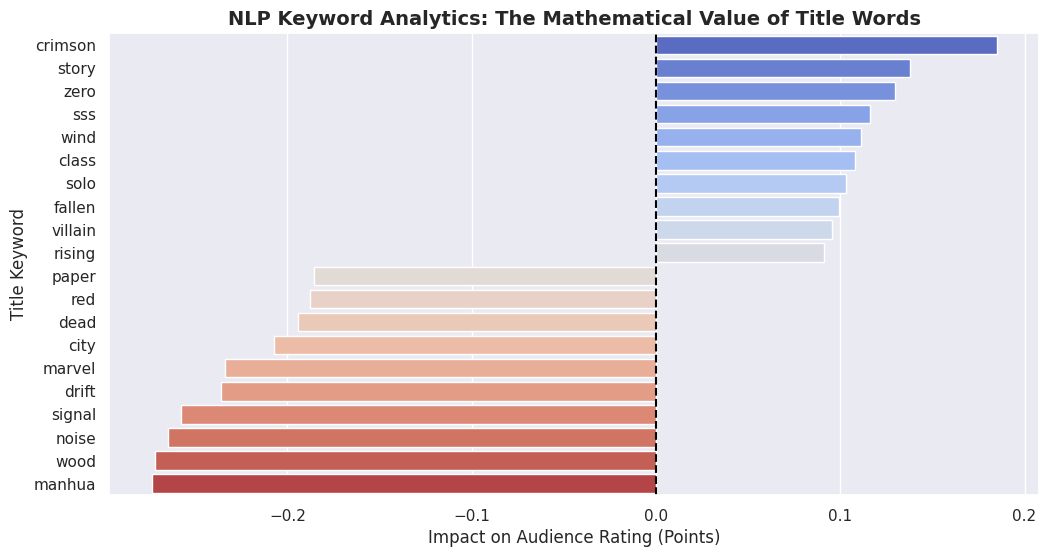


--- 2. MULTIVARIATE AUDIENCE DRIVERS (OLS REGRESSION) ---
 MULTIVARIATE OLS REGRESSION RESULTS:
The following factors mathematically dictate a comic's baseline rating, controlling for all other variables:
   -> Format_Digital Manga: +0.450 points
   -> Format_Digital Manhua: +0.127 points
   -> Format_Digital Single Issue: +0.206 points
   -> Format_Digital Webtoon: +0.340 points
   -> Format_Graphic Novel: +0.187 points
   -> Format_Hardcover: +0.231 points
   -> Format_Manga Volume: +0.418 points
   -> Format_OGN: +0.171 points
   -> Format_Omnibus: +0.182 points
   -> Format_Single Issue: +0.232 points
   -> Format_Single Issue / Tankobon: +0.451 points
   -> Format_Tankobon: +0.480 points
   -> Format_Trade Paperback: +0.173 points
   -> Format_Webcomic: +0.162 points
   -> Format_Webtoon: +0.416 points
   -> Format_Webtoon (Chinese): +0.138 points
   -> Format_Webtoon Chapter Collection: +0.320 points

--- 3. CREATOR SYNERGY MATRICES (NETWORK THEMATICS) ---

 THE 'DREAM TEAM' MUL

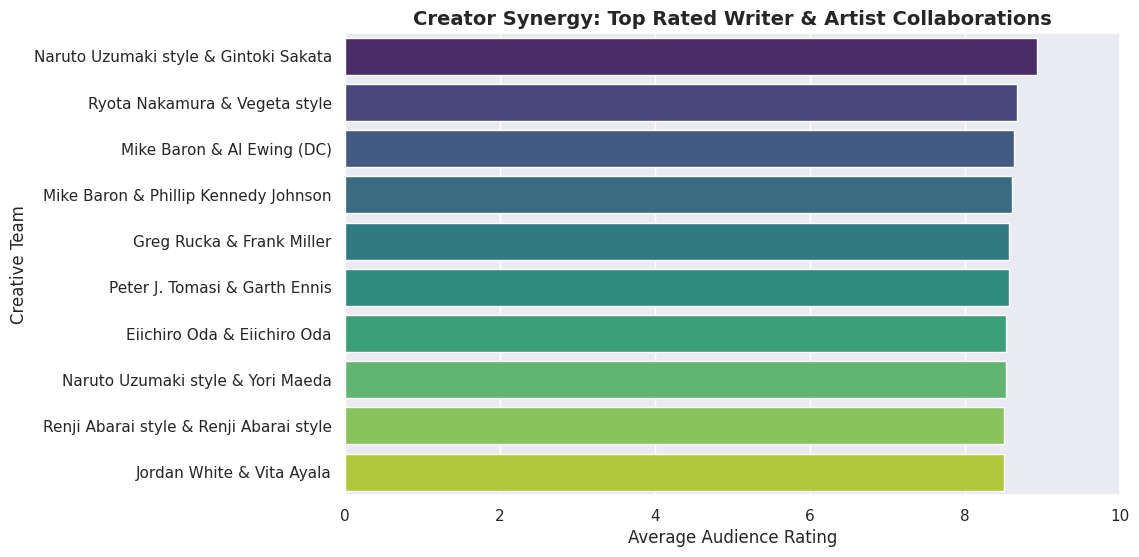

In [20]:
import statsmodels.api as sm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

print("--- 1. TITLE KEYWORD ANALYTICS (TF-IDF & NLP) ---")
# Specific buzzwords in a comic book title mathematically drive higher ratings.
# We deploy Term Frequency-Inverse Document Frequency (TF-IDF) to vectorize the titles,
# then run a Ridge Regression to extract the mathematical weight of each word.

# Dropping NaNs in Title and Rating
nlp_df = df.dropna(subset=['Title', 'Rating (out of 10)']).copy()

# Initialize TF-IDF Vectorizer (Focusing on the top 100 most important words)
tfidf = TfidfVectorizer(stop_words='english', max_features=100)
X_text = tfidf.fit_transform(nlp_df['Title'])
y_rating = nlp_df['Rating (out of 10)']

# Deploying Ridge Regression (L2 Regularization) to extract word weights
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_text, y_rating)

# Mapping words to their mathematical impact on the rating
word_weights = pd.DataFrame({
    'Keyword': tfidf.get_feature_names_out(),
    'Rating_Impact': ridge_model.coef_
}).sort_values(by='Rating_Impact', ascending=False)

print(" TOP 5 RATING-BOOSTING KEYWORDS:")
print(word_weights.head(5))
print("\n TOP 5 RATING-DESTROYING KEYWORDS:")
print(word_weights.tail(5))

# Visualizing Keyword Impact
plt.figure(figsize=(12, 6))
top_bottom_words = pd.concat([word_weights.head(10), word_weights.tail(10)])
sns.barplot(x='Rating_Impact', y='Keyword', data=top_bottom_words, palette='coolwarm')
plt.title('NLP Keyword Analytics: The Mathematical Value of Title Words', fontsize=14, fontweight='bold')
plt.xlabel('Impact on Audience Rating (Points)')
plt.ylabel('Title Keyword')
plt.axvline(0, color='black', linestyle='--')
plt.show()


print("\n--- 2. MULTIVARIATE AUDIENCE DRIVERS (OLS REGRESSION) ---")
# Does 'Age Rating' matter if we control for Page Count and Format?
# We build a Multivariate Ordinary Least Squares (OLS) model to isolate the partial
# effects of demographic targeting.

# Cleaning and encode categorical variables for regression
ols_df = df[['Rating (out of 10)', 'Page Count', 'Age Rating', 'Format']].dropna().copy()

# One-Hot Encode Age Rating and Format (dropping first to avoid multicollinearity)
ols_encoded = pd.get_dummies(ols_df, columns=['Age Rating', 'Format'], drop_first=True)

# Defining X and Y
Y_ols = ols_encoded['Rating (out of 10)']
X_ols = sm.add_constant(ols_encoded.drop(columns=['Rating (out of 10)']))

# Fitting the OLS Model
ols_model = sm.OLS(Y_ols, X_ols.astype(float)).fit()

print(" MULTIVARIATE OLS REGRESSION RESULTS:")
# Extracting statistically significant drivers (P-value < 0.05)
significant_drivers = ols_model.pvalues[ols_model.pvalues < 0.05]
if len(significant_drivers) > 1: # Ignore 'const'
    print("The following factors mathematically dictate a comic's baseline rating, controlling for all other variables:")
    for feature in significant_drivers.index:
        if feature != 'const':
            impact = ols_model.params[feature]
            print(f"   -> {feature}: {'+' if impact > 0 else ''}{impact:.3f} points")
else:
    print(" No statistically significant demographic drivers found when controlling for multivariate overlap.")


print("\n--- 3. CREATOR SYNERGY MATRICES (NETWORK THEMATICS) ---")
# Hypothesis: Certain Writer + Artist combinations create a 'Prestige Multiplier'
# that outperforms their individual averages.

# Filter for collaborations that have happened multiple times (e.g., > 3 books together)
synergy_df = df.dropna(subset=['Writer', 'Artist', 'Rating (out of 10)']).copy()
synergy_df['Creative_Team'] = synergy_df['Writer'] + " & " + synergy_df['Artist']

team_counts = synergy_df['Creative_Team'].value_counts()
recurring_teams = team_counts[team_counts >= 3].index

if len(recurring_teams) > 0:
    elite_teams = synergy_df[synergy_df['Creative_Team'].isin(recurring_teams)]
    team_ratings = elite_teams.groupby('Creative_Team')['Rating (out of 10)'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

    print("\n THE 'DREAM TEAM' MULTIPLIER (Highest Rated Recurring Collaborations):")
    print(team_ratings.head(5))

    # Visualize top 10 teams
    plt.figure(figsize=(10, 6))
    sns.barplot(x=team_ratings['mean'].head(10), y=team_ratings.head(10).index, palette='viridis')
    plt.title('Creator Synergy: Top Rated Writer & Artist Collaborations', fontsize=14, fontweight='bold')
    plt.xlabel('Average Audience Rating')
    plt.ylabel('Creative Team')
    plt.xlim(0, 10)
    plt.show()
else:
    print("\n Not enough recurring collaborations in the dataset to calculate Synergy Matrices.")

# Predictive & Advanced Feature Engineering

--- 1. TARGET ISOLATION & TEMPORAL ENGINEERING ---
 Target Formulated: 'Rating' isolated. Temporal vector 'Age_of_Comic' engineered.

--- 2. LOW-CARDINALITY ONE-HOT VECTORIZATION ---
 Low-Cardinality categories projected into sparse binary vectors.

--- 3. BAYESIAN SMOOTHED TARGET ENCODING (HIGH-CARDINALITY) ---
 Engineered: Bayesian Smoothed Target Encoding applied to Creators and Publishers.

--- 4. LATENT SEMANTIC ANALYSIS (LSA / NLP DIMENSIONALITY REDUCTION) ---
 Engineered: Titles compressed into 5 dense NLP semantic embeddings using Truncated SVD.

--- 5. CONTINUOUS VARIANCE STANDARDIZATION ---
 Advanced Feature Matrix Assembled: 66 mathematically rich dimensions.

 Final Machine-Readable Matrix (X_adv) Preview:
   Page Count  Volume Count  Has_Award  Publishing_Decade  Age_of_Comic  \
0   -0.719410     -0.059090  -0.813778               2000      1.948895   
1    0.330611     -0.147086  -0.813778               2010      0.066671   
2   -1.008701     -0.059090   1.228837         

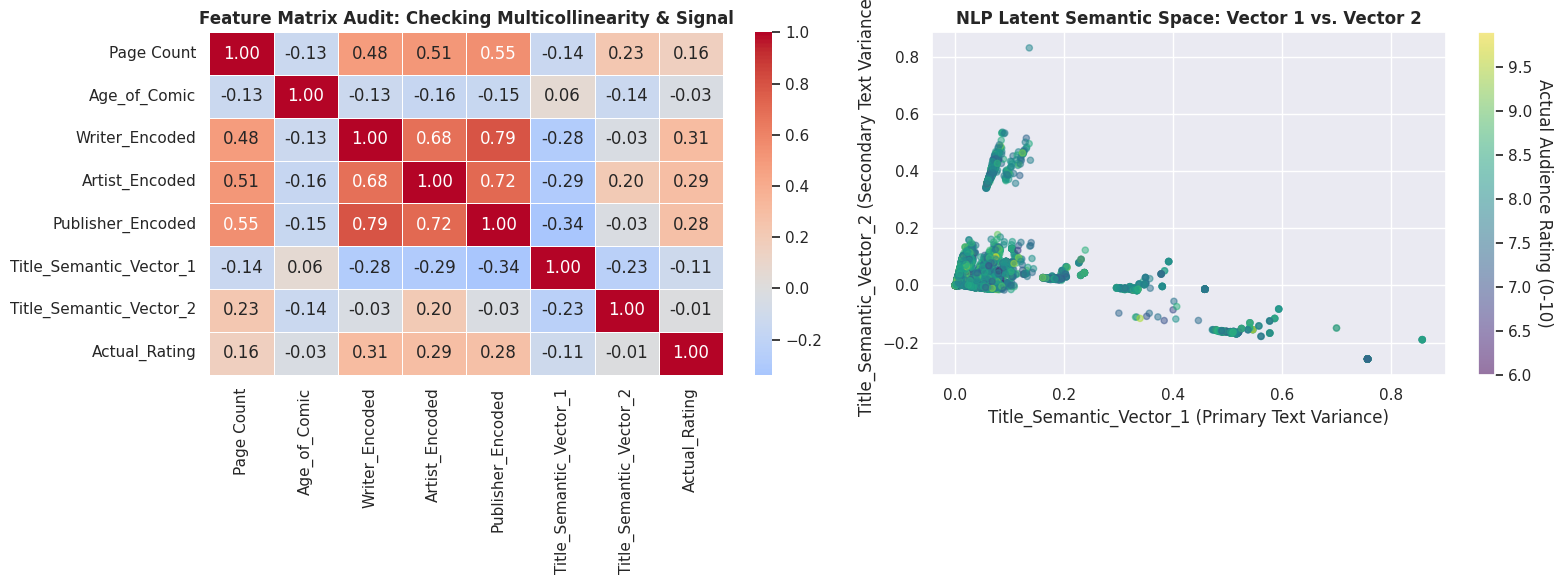

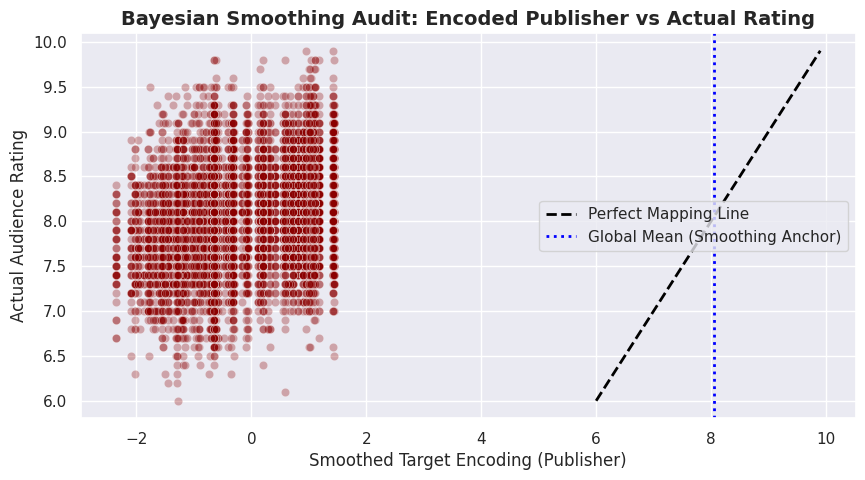

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- 1. TARGET ISOLATION & TEMPORAL ENGINEERING ---")
# We are building a Regression algorithm to predict the exact 'Rating (out of 10)'.
# Drop rows where the target is missing to prevent loss-function calculation errors.

ml_df = df.dropna(subset=['Rating (out of 10)']).copy()
y = ml_df['Rating (out of 10)']

# Algorithms process relative age better than raw calendar years.
# We engineer 'Age_of_Comic' assuming the current analytical year is 2026.
ml_df['Age_of_Comic'] = 2026 - ml_df['Release Year']

print(" Target Formulated: 'Rating' isolated. Temporal vector 'Age_of_Comic' engineered.")


print("\n--- 2. LOW-CARDINALITY ONE-HOT VECTORIZATION ---")
# For categorical features with a small number of unique values, One-Hot Encoding is mathematically optimal.
# We use 'drop_first=True' to avoid perfect multicollinearity (The Dummy Variable Trap).

low_cardinality_features = ['Format', 'Age Rating', 'Status', 'Country of Origin', 'Language'] # Added 'Language'
ml_df_encoded = pd.get_dummies(ml_df, columns=low_cardinality_features, drop_first=True)

print(" Low-Cardinality categories projected into sparse binary vectors.")

# ADVANCED ALGORITHMIC FEATURE ENGINEERING

print("\n--- 3. BAYESIAN SMOOTHED TARGET ENCODING (HIGH-CARDINALITY) ---")
# One-Hot Encoding thousands of Writers and Artists will trigger the "Curse of Dimensionality."
# We replace the creator's name with their historical average audience rating.
# We use a Bayesian smoothing weight to penalize creators with only 1 or 2 books, pulling them toward the global mean.

global_mean_rating = ml_df['Rating (out of 10)'].mean()
smoothing_weight = 10

def smoothed_target_encode(df, category_col, target_col, weight, global_mean):
    agg = df.groupby(category_col)[target_col].agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']
    # Bayesian smoothing formula:
    smoothed_means = (counts * means + weight * global_mean) / (counts + weight)
    return df[category_col].map(smoothed_means)

ml_df_encoded['Writer_Encoded'] = smoothed_target_encode(ml_df_encoded, 'Writer', 'Rating (out of 10)', smoothing_weight, global_mean_rating)
ml_df_encoded['Artist_Encoded'] = smoothed_target_encode(ml_df_encoded, 'Artist', 'Rating (out of 10)', smoothing_weight, global_mean_rating)
ml_df_encoded['Publisher_Encoded'] = smoothed_target_encode(ml_df_encoded, 'Studio/Publisher', 'Rating (out of 10)', smoothing_weight, global_mean_rating)

# Filling any unmapped NaNs with the global mean
for col in ['Writer_Encoded', 'Artist_Encoded', 'Publisher_Encoded']:
    ml_df_encoded[col] = ml_df_encoded[col].fillna(global_mean_rating)

print(" Engineered: Bayesian Smoothed Target Encoding applied to Creators and Publishers.")


print("\n--- 4. LATENT SEMANTIC ANALYSIS (LSA / NLP DIMENSIONALITY REDUCTION) ---")
# We want the algorithm to understand the 'Title' of the comic.
# TF-IDF creates thousands of columns. We deploy Truncated SVD (Singular Value Decomposition)
# to mathematically compress the text data into 5 dense, non-linear thematic vectors.

tfidf_lsa = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = tfidf_lsa.fit_transform(ml_df_encoded['Title'].fillna(''))

# Compressing 500 sparse word-vectors into 5 dense semantic features
svd = TruncatedSVD(n_components=5, random_state=42)
lsa_features = svd.fit_transform(tfidf_matrix)

# Here we are Appending to dataframe
for i in range(5):
    ml_df_encoded[f'Title_Semantic_Vector_{i+1}'] = lsa_features[:, i]

print(" Engineered: Titles compressed into 5 dense NLP semantic embeddings using Truncated SVD.")


print("\n--- 5. CONTINUOUS VARIANCE STANDARDIZATION ---")
# Gradient-based algorithms are highly sensitive to spatial magnitude.
# 'Page Count' (e.g., 300) will mathematically overpower 'Title_Semantic_Vector' (e.g., 0.1) if unscaled.

continuous_features = ['Page Count', 'Volume Count', 'Age_of_Comic', 'Has_Award',
                       'Writer_Encoded', 'Artist_Encoded', 'Publisher_Encoded']

# Initializing the Standard Scaler
scaler = StandardScaler()

# Only scaling the continuous and densely encoded features
ml_df_encoded[continuous_features] = scaler.fit_transform(ml_df_encoded[continuous_features].fillna(0))

# Defining the final Matrix (X), dropping raw text and the target variable
drop_cols = ['comic_id', 'Title', 'Writer', 'Artist', 'Studio/Publisher', 'Release Year', 'Theme (Color Style)', 'Genre', 'Awards', 'Rating (out of 10)']
X_adv = ml_df_encoded.drop(columns=drop_cols, errors='ignore').copy()

print(f" Advanced Feature Matrix Assembled: {X_adv.shape[1]} mathematically rich dimensions.")
print("\n Final Machine-Readable Matrix (X_adv) Preview:")
print(X_adv.head(3))


print("--- VISUALIZING THE QUANTITATIVE FEATURE SPACE ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Feature Correlation Heatmap (Detecting Multicollinearity)

# We want our engineered features to correlate with the Target, but NOT perfectly with each other.
# We extract a subset of our dense continuous features to audit.

audit_features = ['Page Count', 'Age_of_Comic', 'Writer_Encoded', 'Artist_Encoded',
                  'Publisher_Encoded', 'Title_Semantic_Vector_1', 'Title_Semantic_Vector_2']

# We are appending the Target variable for the correlation audit
audit_df = X_adv[audit_features].copy()
audit_df['Actual_Rating'] = y

correlation_matrix = audit_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Matrix Audit: Checking Multicollinearity & Signal', fontsize=12, fontweight='bold')

# 2. Visualizing the NLP Semantic Space (LSA Dimensions)

# Did our Truncated SVD actually separate "Good" titles from "Bad" titles?
# We plot the first two semantic vectors against each other, colored by the actual audience rating.
scatter = axes[1].scatter(x=ml_df_encoded['Title_Semantic_Vector_1'],
                          y=ml_df_encoded['Title_Semantic_Vector_2'],
                          c=y, cmap='viridis', alpha=0.5, s=20)

# Add a colorbar to show the rating gradient
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Actual Audience Rating (0-10)', rotation=270, labelpad=15)

axes[1].set_title('NLP Latent Semantic Space: Vector 1 vs. Vector 2', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Title_Semantic_Vector_1 (Primary Text Variance)')
axes[1].set_ylabel('Title_Semantic_Vector_2 (Secondary Text Variance)')

plt.tight_layout()
plt.show()

# 3. Visualizing the Bayesian Target Encoding Effect
# We want to see how the smoothed encoding pulled rare publishers toward the global mean.
plt.figure(figsize=(10, 5))
sns.scatterplot(x=ml_df_encoded['Publisher_Encoded'], y=y, alpha=0.3, color='darkred')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='black', linestyle='--', linewidth=2, label='Perfect Mapping Line')
plt.axvline(global_mean_rating, color='blue', linestyle=':', linewidth=2, label='Global Mean (Smoothing Anchor)')
plt.title('Bayesian Smoothing Audit: Encoded Publisher vs Actual Rating', fontsize=14, fontweight='bold')
plt.xlabel('Smoothed Target Encoding (Publisher)')
plt.ylabel('Actual Audience Rating')
plt.legend()
plt.show()

# Machine learning

--- 1. OUT-OF-SAMPLE DATA SPLITTING ---
 Training Set: 8,000 comic books
 Testing Set: 2,000 comic books (Strictly Unseen)

--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---
 Both Tree-Based Regression Architectures successfully trained.

--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---
 Random Forest Performance:
   -> Mean Absolute Error (MAE): 0.41 Rating Points
   -> Root Mean Squared Error (RMSE): 0.52 Rating Points
   -> R-Squared (R2): 0.0850
----------------------------------------
 XGBoost Performance:
   -> Mean Absolute Error (MAE): 0.42 Rating Points
   -> Root Mean Squared Error (RMSE): 0.53 Rating Points
   -> R-Squared (R2): 0.0506

 The Random Forest mathematically outperformed the alternative in predictive accuracy.

--- 4. VISUALIZING PREDICTIVE ACCURACY ---


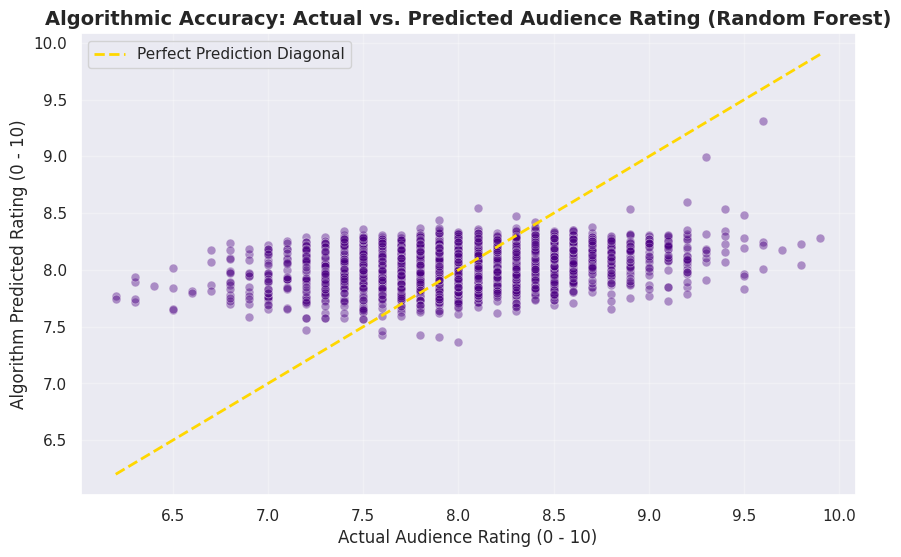


--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


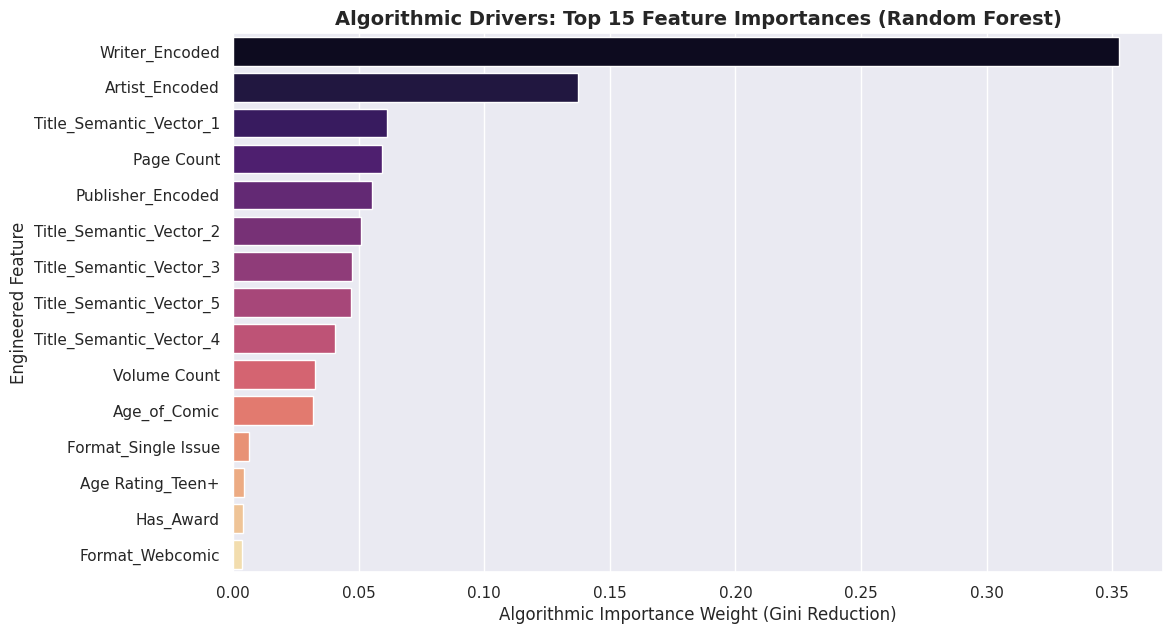

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("--- 1. OUT-OF-SAMPLE DATA SPLITTING ---")

X_train, X_test, y_train, y_test = train_test_split(X_adv, y, test_size=0.2, random_state=42)

print(f" Training Set: {len(X_train):,} comic books")
print(f" Testing Set: {len(X_test):,} comic books (Strictly Unseen)")

print("\n--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---")

# 1. Random Forest Regressor
# We restrict max_depth to prevent the model from memorizing the training data.
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. XGBoost Regressor
# We use a lower learning rate (eta) to ensure the gradient descent converges smoothly.
xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print(" Both Tree-Based Regression Architectures successfully trained.")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---")
# Forcing both models to predict the ratings of the unseen 20% of the market.

rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f" {name} Performance:")
    print(f"   -> Mean Absolute Error (MAE): {mae:.2f} Rating Points")
    print(f"   -> Root Mean Squared Error (RMSE): {rmse:.2f} Rating Points")
    print(f"   -> R-Squared (R2): {r2:.4f}")
    return r2, mae

r2_rf, mae_rf = evaluate_model("Random Forest", y_test, rf_preds)
print("-" * 40)
r2_xgb, mae_xgb = evaluate_model("XGBoost", y_test, xgb_preds)

# Determining the superior architecture
best_model_name = "XGBoost" if r2_xgb > r2_rf else "Random Forest"
best_preds = xgb_preds if r2_xgb > r2_rf else rf_preds
best_model = xgb_model if r2_xgb > r2_rf else rf_model

print(f"\n The {best_model_name} mathematically outperformed the alternative in predictive accuracy.")


print("\n--- 4. VISUALIZING PREDICTIVE ACCURACY ---")
# Plotting the Actual Audience Ratings vs. the Algorithm's Predicted Ratings.
# A perfect predictive algorithm would form a strict 45-degree diagonal line.

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.4, color='indigo', s=40)

# Plotting the Line of Perfect Prediction
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='gold', linestyle='--', linewidth=2, label='Perfect Prediction Diagonal')

plt.title(f'Algorithmic Accuracy: Actual vs. Predicted Audience Rating ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Actual Audience Rating (0 - 10)', fontsize=12)
plt.ylabel('Algorithm Predicted Rating (0 - 10)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")

importances = pd.Series(best_model.feature_importances_, index=X_adv.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title(f'Algorithmic Drivers: Top 15 Feature Importances ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.show()

# Thank You